In [1]:
import yfinance as yf
ticker = yf.Ticker('AAPL')

import datetime

import matplotlib.pyplot as plt
import pandas as pd

from optionanalytics.data.yahoo import fetch_option_chain
from optionanalytics.cleaning.filters import clean_option_chain
from optionanalytics.cleaning.arbitrage import filter_price_bound_violations
from optionanalytics.models.market import MarketData
from optionanalytics.volatility.smile import build_smile

ticker = "AAPL"
expiry = "2026-08-21"

valuation_date = datetime.date(2026, 7, 18)

market_data = MarketData(
    spot=333.74,
    risk_free_rate=0.0418,
    volatility=0.20,      # Placeholder
)

In [2]:
chain = fetch_option_chain(ticker, expiry)

clean_chain = clean_option_chain(chain)

clean_chain = filter_price_bound_violations(
    clean_chain,
    market_data,
    valuation_date,
)

smile = build_smile(
    clean_chain,
    market_data,
    valuation_date,
)

#### Plotting raw market points

Text(0, 0.5, 'Implied Volatility')

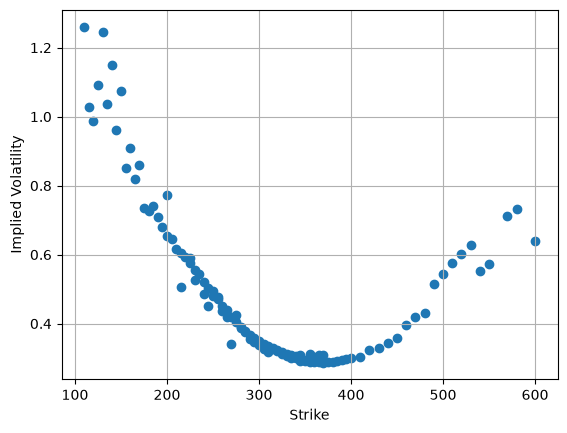

In [3]:
strikes = [p.strike for p in smile.points]
ivs = [p.implied_volatility for p in smile.points]

plt.scatter(strikes, ivs, label="Market Quotes")
plt.grid(True)
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")

#### Plot interpolated curve

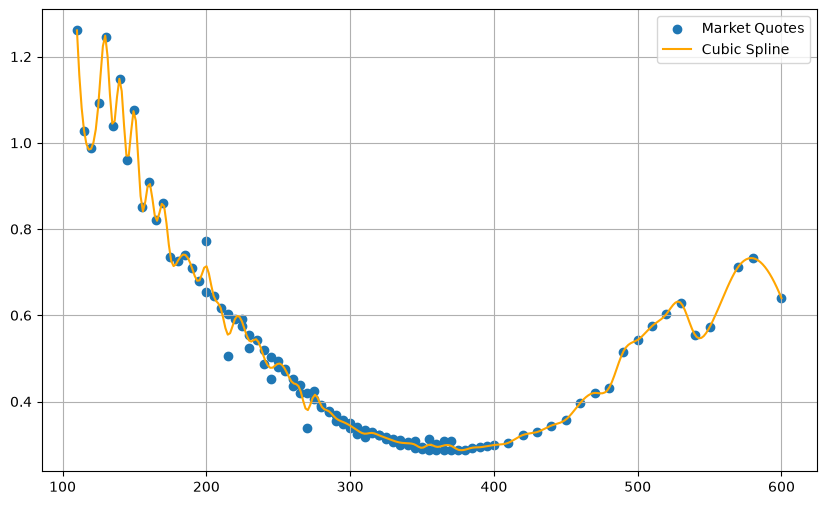

In [5]:
import numpy as np
from optionanalytics.volatility.interpolation import interpolate_smile
from optionanalytics.models.enums import InterpolationMethod

interpolator = interpolate_smile(smile, InterpolationMethod.CUBIC_SPLINE)

grid = np.linspace(min(strikes), max(strikes), 300)

interp_iv = interpolator(grid)

plt.figure(figsize=(10,6))

plt.scatter(strikes, ivs, label="Market Quotes")
plt.plot(grid, interp_iv, label="Cubic Spline", color='orange')

plt.legend()
plt.grid(True)

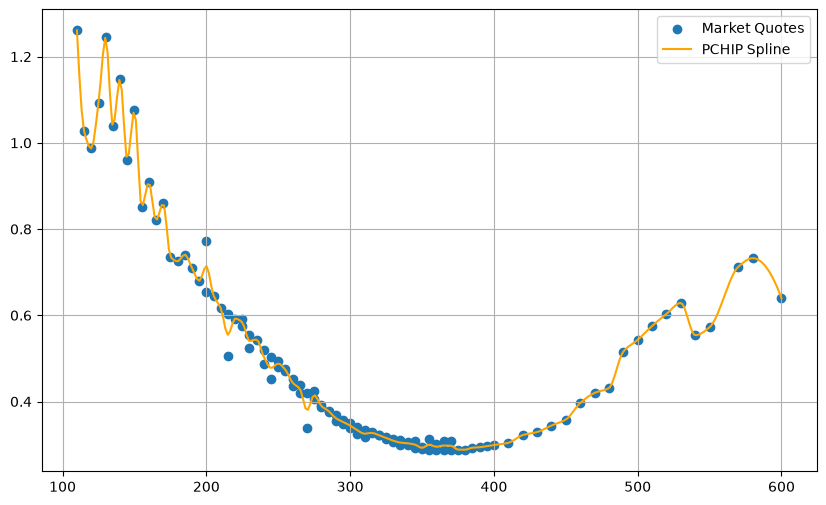

In [6]:
interpolator = interpolate_smile(smile, InterpolationMethod.PCHIP)

grid = np.linspace(min(strikes), max(strikes), 300)

interp_iv = interpolator(grid)

plt.figure(figsize=(10,6))

plt.scatter(strikes, ivs, label="Market Quotes")
plt.plot(grid, interp_iv, label="PCHIP Spline", color='orange')

plt.legend()
plt.grid(True)

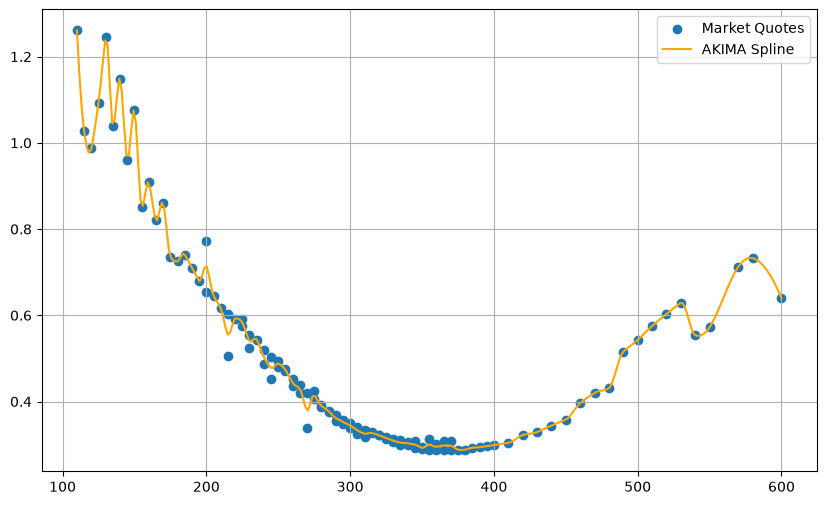

In [7]:
interpolator = interpolate_smile(smile, InterpolationMethod.AKIMA)

grid = np.linspace(min(strikes), max(strikes), 300)

interp_iv = interpolator(grid)

plt.figure(figsize=(10,6))

plt.scatter(strikes, ivs, label="Market Quotes")
plt.plot(grid, interp_iv, label="AKIMA Spline", color='orange')

plt.legend()
plt.grid(True)

#### Comparison across different interpolation methods

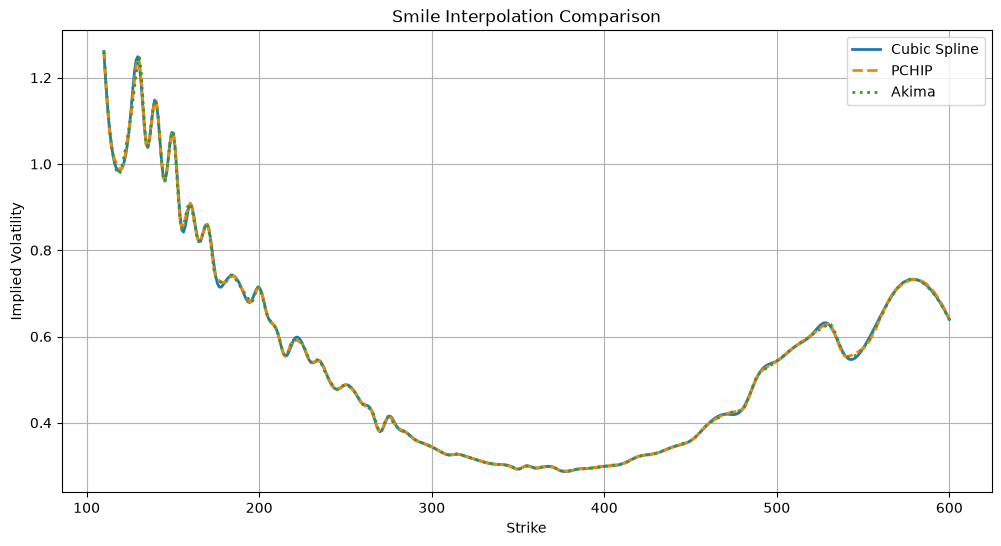

In [24]:
strikes = [p.strike for p in smile.points]
ivs = [p.implied_volatility for p in smile.points]

grid = np.linspace(min(strikes), max(strikes), 500)

cubic = interpolate_smile(smile, InterpolationMethod.CUBIC_SPLINE)
pchip = interpolate_smile(smile, InterpolationMethod.PCHIP)
akima = interpolate_smile(smile, InterpolationMethod.AKIMA)

plt.figure(figsize=(12,6))

# plt.scatter(
#     strikes,
#     ivs,
#     color="black",
#     s=40,
#     label="Market Quotes",
#     zorder=5,
# )

plt.plot(grid, cubic(grid), linewidth=2, label="Cubic Spline")
plt.plot(grid, pchip(grid), linewidth=2, linestyle="--", label="PCHIP")
plt.plot(grid, akima(grid), linewidth=2, linestyle=":", label="Akima")

plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("Smile Interpolation Comparison")
plt.grid(True)
plt.legend()

plt.show()

##### Comparison with subset of smile points

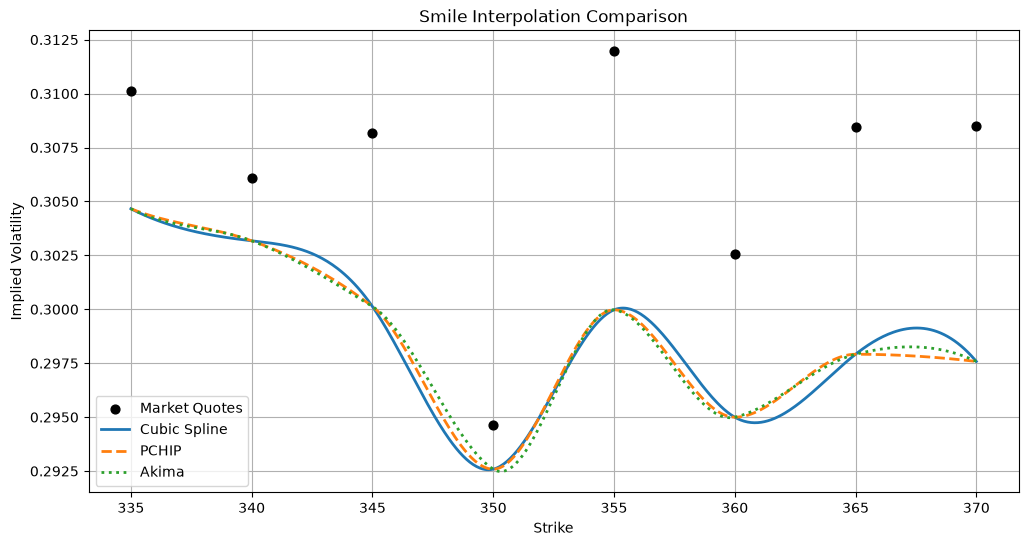

In [26]:
strikes = [p.strike for p in smile.points[100:]]
ivs = [p.implied_volatility for p in smile.points[100:]]

grid = np.linspace(min(strikes), max(strikes), 500)

cubic = interpolate_smile(smile, InterpolationMethod.CUBIC_SPLINE)
pchip = interpolate_smile(smile, InterpolationMethod.PCHIP)
akima = interpolate_smile(smile, InterpolationMethod.AKIMA)

plt.figure(figsize=(12,6))

plt.scatter(
    strikes,
    ivs,
    color="black",
    s=40,
    label="Market Quotes",
    zorder=5,
)

plt.plot(grid, cubic(grid), linewidth=2, label="Cubic Spline")
plt.plot(grid, pchip(grid), linewidth=2, linestyle="--", label="PCHIP")
plt.plot(grid, akima(grid), linewidth=2, linestyle=":", label="Akima")

plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("Smile Interpolation Comparison")
plt.grid(True)
plt.legend()

plt.show()